**PRCP-1020-House Price Prediction(Advanced Regression)**

**Domain Analysis**

House Price Prediction comes under the real estate domain. This domain focuses on analysing property related data to understand how various factors influence house prices and to build predictive models which can estimate property values accurately. Real estate price is influenced by multiple factors such as location, size, no.of.rooms and available amentities.Accurate price prediction helps buyers,sellers and real estate companies make informer decisions.
Real estate price prediction plays a crucial role in decision making for buyers, sellers, investors and developers. Machine learning helps to uncover hidden patterns in property data that traditional pricing methods may overlook.Accurate predictions can reduce financial risk, imrpove investment planning, and support fair market valuation.

**Problem Statement:**
The objective of this project is to build an advanced regression model to accurately predict house proces based on various residential property features.The dataset contains both numerical and categorical variables related to location, property size, construction quality,amenitites and sale conditions.Since real estate prices are infuenced by multiple interacting factors and may contain missing values, outliers and skewed distributions,robust preprocessing and feature handling are required.

The goal is to perform data preprocessing,exploratory data analysis,feature transformation and model building using machine learning techniques and to evaluate model performance using appropriate regression metrics such as RMSE,MAE and r2_score


In [ ]:
# Import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression

**Load Dataset**

In [ ]:
# Load the data
data = pd.read_csv("/content/data.csv")

**Basic Checks**

In [ ]:
# Shape of data
data.shape

(1460, 81)

In [ ]:
# check info of data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
# First 5 rows of data
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# check all column names are in readable format.
data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [ ]:
# Last 5 row of data
data.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [ ]:
# check for duplicates
data.duplicated().sum()

np.int64(0)

In [ ]:
# check for null values
data.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


**EDA(Exploratory Data Analysis)**

**Univariate Analysis:**

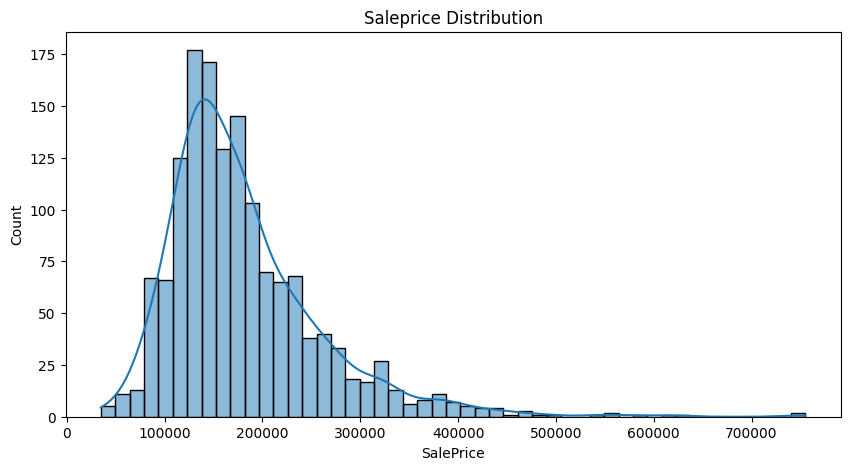

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data['SalePrice'],kde=True)
plt.title("Saleprice Distribution")
plt.show()

**Insights:**
The target column(saleprice) is right skewed. Applied log transformation to reduce skewness and stabilize variance.

In [ ]:
# Apply log transformation on target column.
data['SalePrice_log'] = np.log1p(data['SalePrice'])

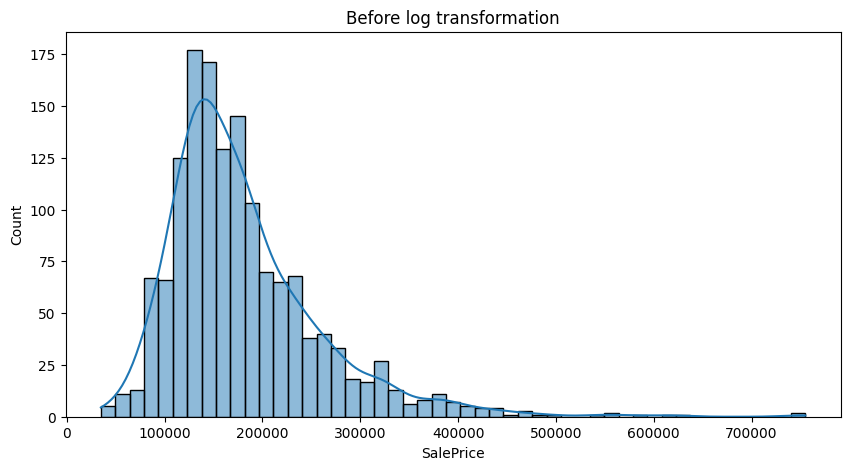

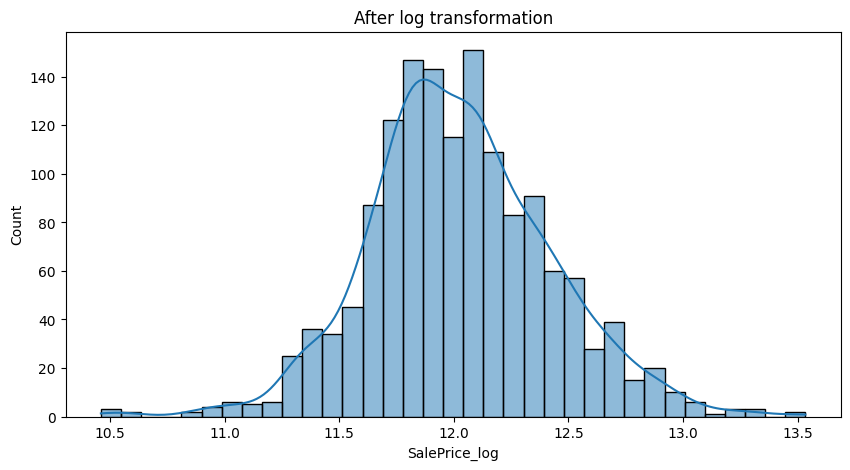

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data['SalePrice'],kde=True)
plt.title("Before log transformation")
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(data['SalePrice_log'],kde=True)
plt.title("After log transformation")
plt.show()

**Insights:**
The distribution after transformation appears more symmetric, which helps regression modela will perform better.

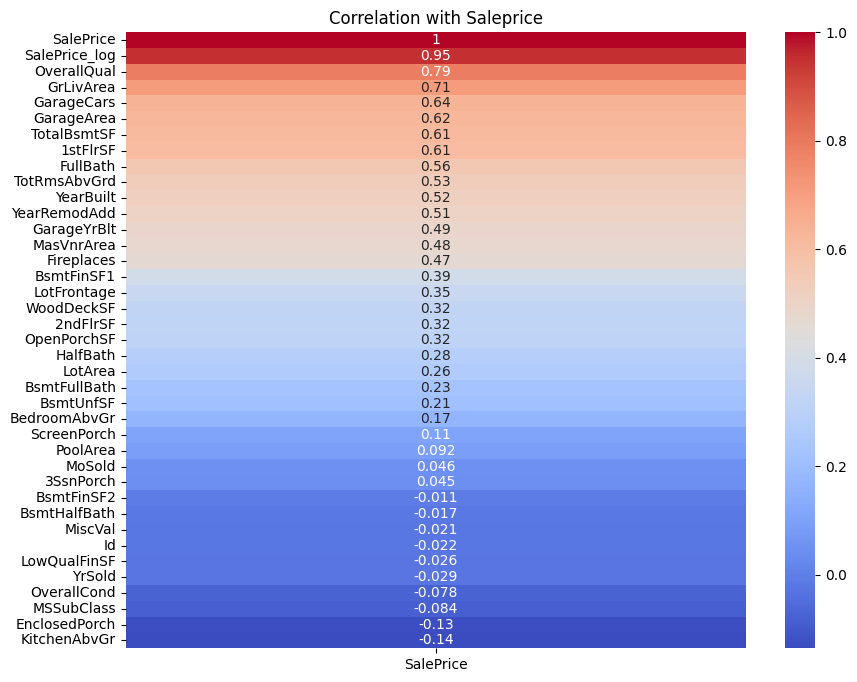

In [ ]:
# Correlation of numeric columns
num_cols = data.select_dtypes(include=np.number)
corr = num_cols.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr[['SalePrice']].sort_values(by='SalePrice',ascending=False),
            annot=True,cmap='coolwarm')
plt.title("Correlation with Saleprice")
plt.show()

**Insights:**
According to this correaltion map, features such as overallqual,GrLivArea, and TotalBsmtSF show strong positive correlation with saleprice, indicating that better construction quality and larger living area significantly increases house prices.

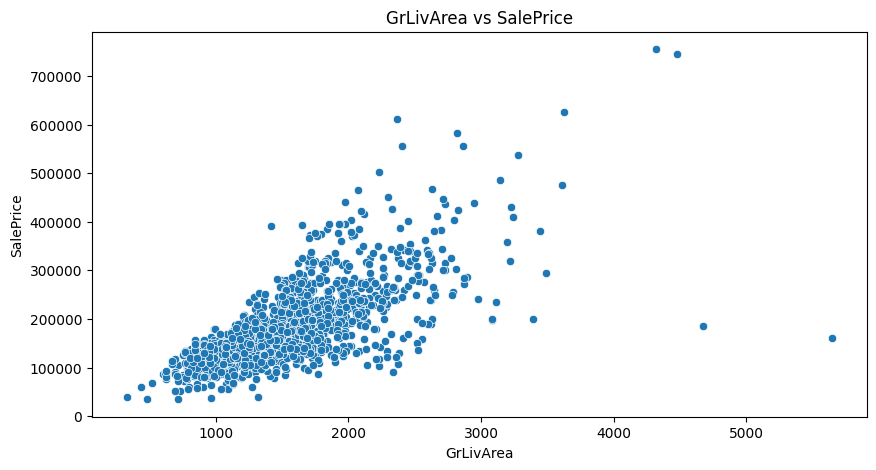

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(x=data['GrLivArea'],y=data['SalePrice'])
plt.title("GrLivArea vs SalePrice")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.show()

**Insights:**
This plot shows strong positive relationship between GrLivArea and SalePrice.A linear upward trend is visible, so tha GrLivArea is one of the most influential predictors of house price.

**Key Insights(EDA):**
* OverallQual has a strong positive correlation with saleprice,indicating that better material and finish quality significantly increase house value.

* GrLivArea and TotalBsmtSF are major contributors to price, showing that larger living and basement areas lead to higher sale prices.

* Neighborhood plays a crucial role in price variation, highlighting the importance of location in real estate valuation.




**Business Insights from EDA**

* Houses with higher overall quality ratings significantly increasee sale price.
*  Improving construction quality can direclty increase property valuation.
* Investors should prioritize quality upgrades over cosmetic changes.



In [ ]:
# Drop unnecessary columns
data.drop(columns=['Id'],inplace=True)

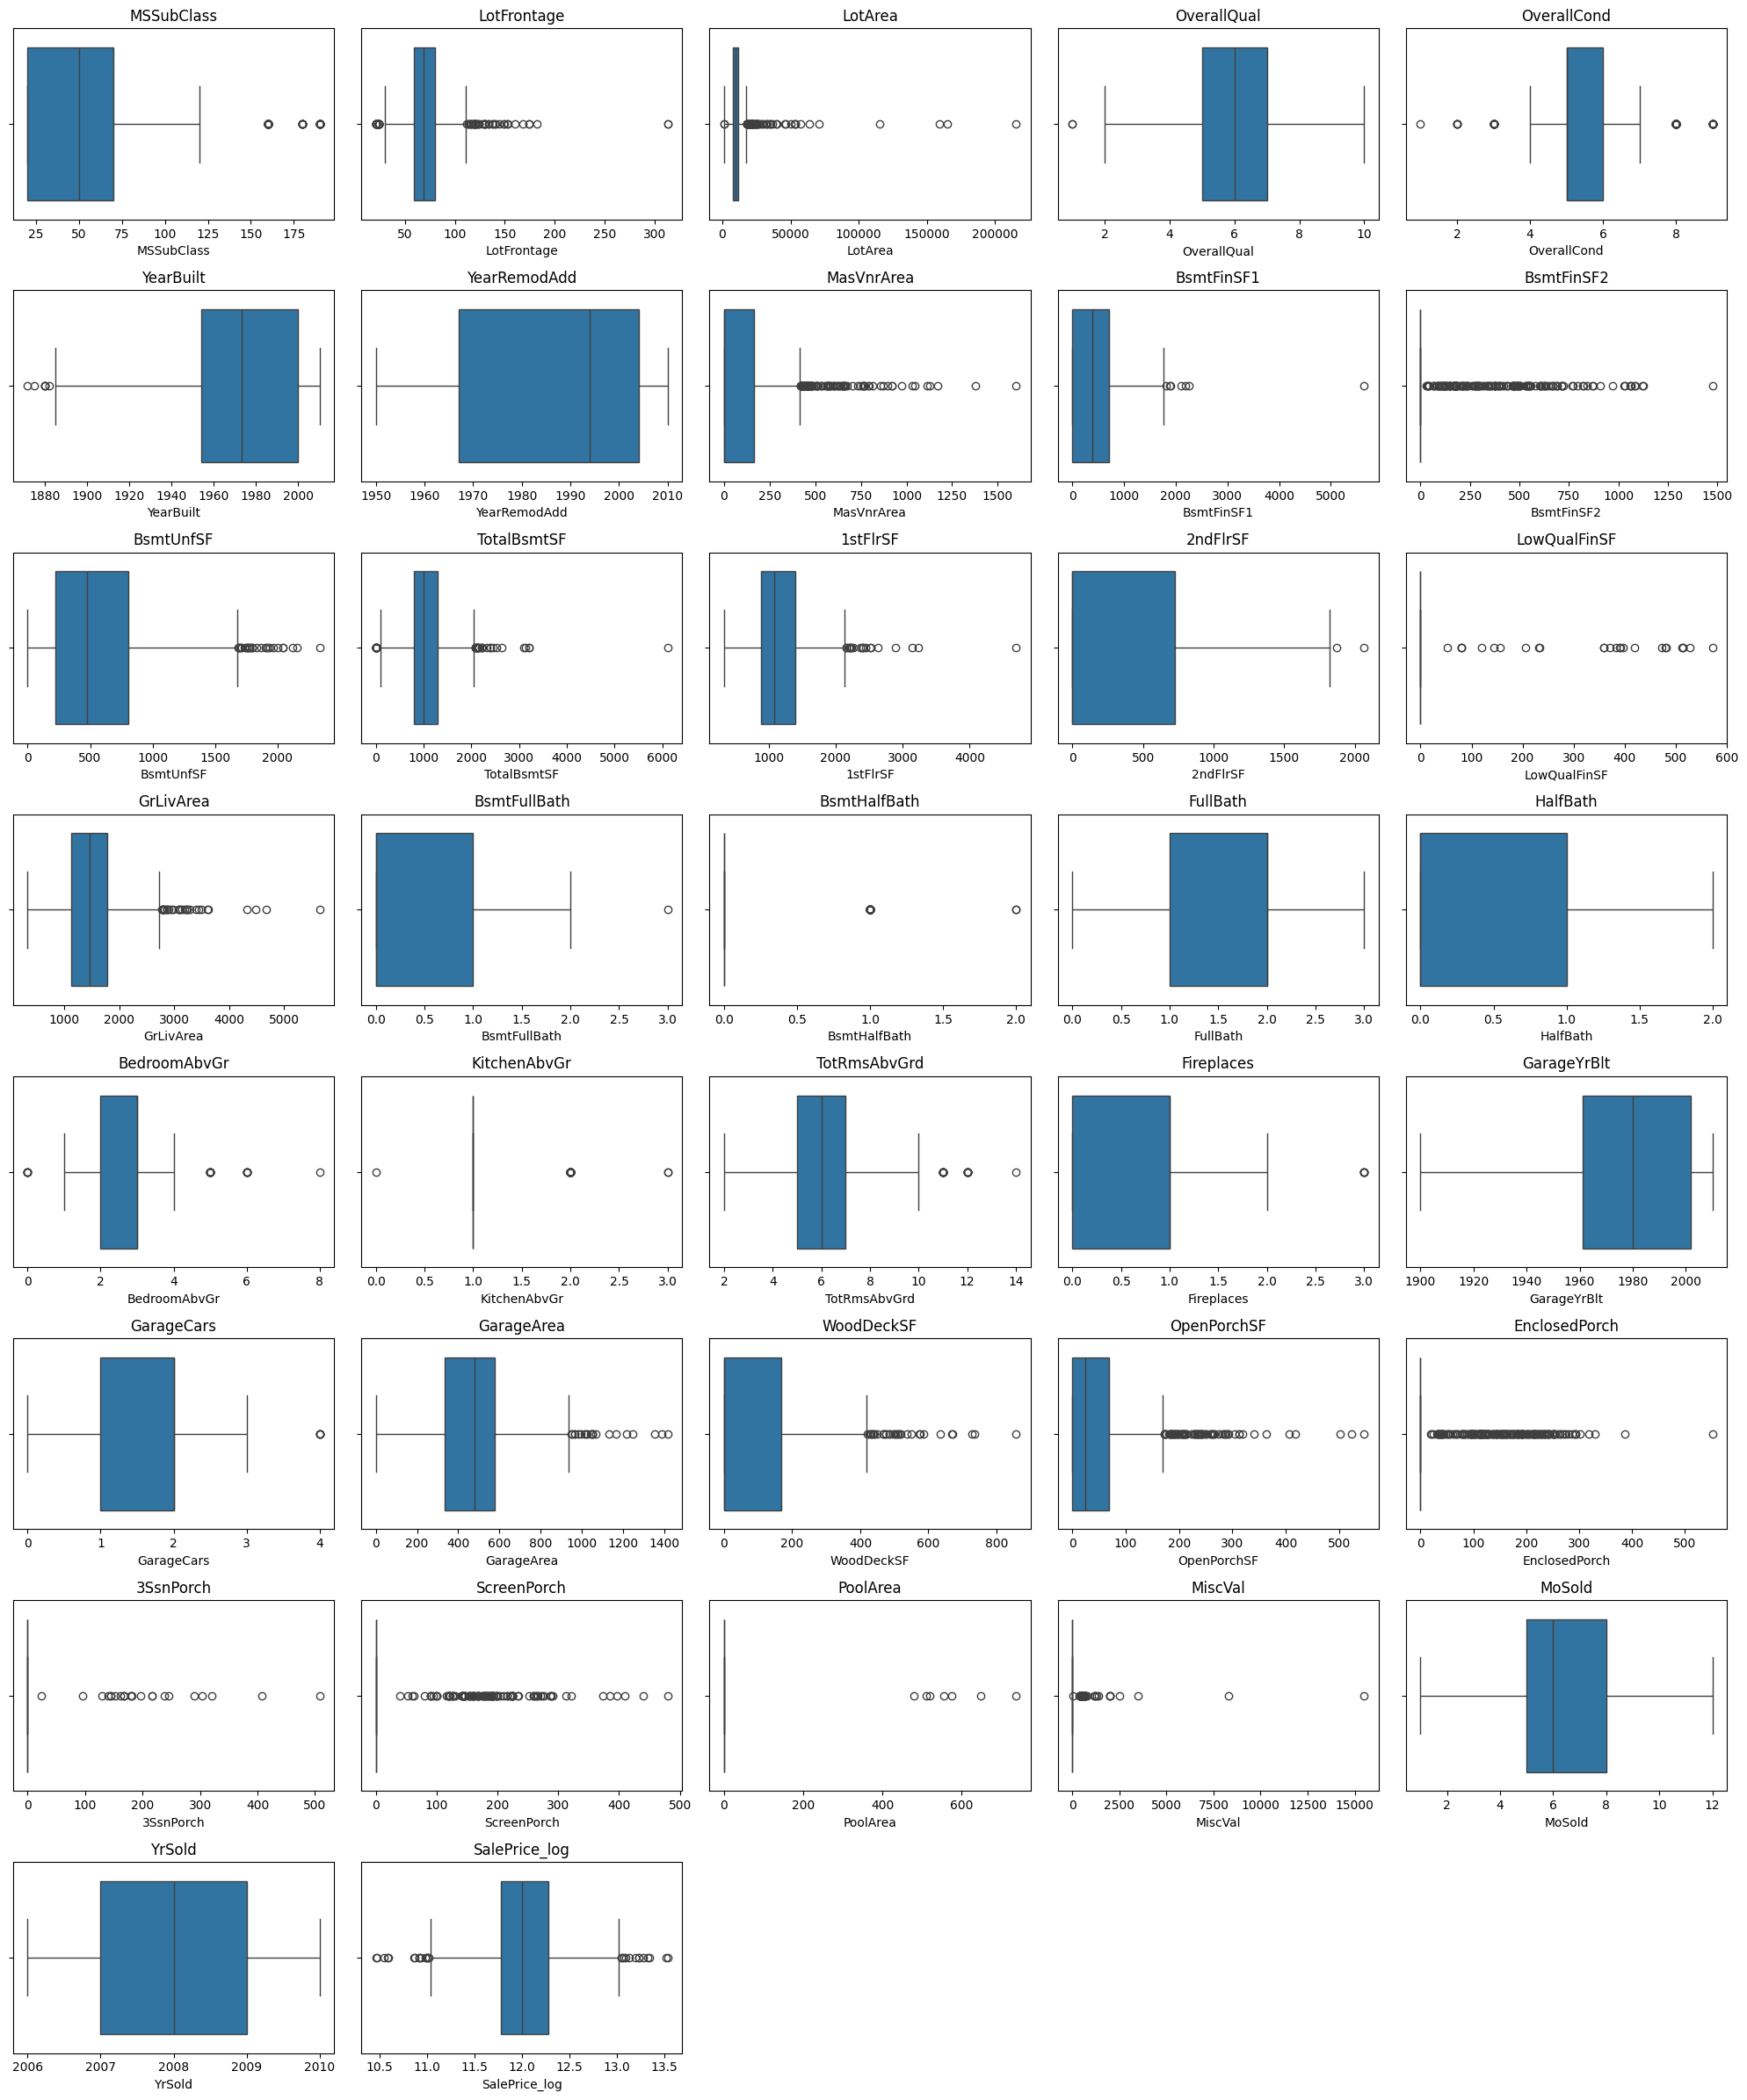

In [ ]:
# Outliers plot
import math

num_cols = data.select_dtypes(include=np.number).columns.drop('SalePrice')
n = len(num_cols)
# This(ceil) helps to calculate the rows automatically
cols = 5
rows = math.ceil(n / cols)

plt.figure(figsize=(cols*4,rows*3))
for i, col in enumerate(num_cols, 1):
  plt.subplot(rows, cols, i)
  sns.boxplot(x = data[col])
  plt.title(col)
plt.tight_layout()
plt.show()

In [ ]:
# Divide data for train and test
X = data.drop('SalePrice',axis=1)
y = data['SalePrice_log']

In [ ]:
# Separate numerical and categorial columns
numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(include='object').columns

In [ ]:
# Separating the data into train and test with size and random state
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,random_state=42
    )

**Capping Outliers:**
Capping outliers helps models like LinearRegression and  GradientBoosting by preventing extreme values from dominating the loss function, while tree based models remain unaffected.This ensures consistency across all the models.


In [ ]:
# Capping outliers so it prevents the data leakage.
from sklearn.base import BaseEstimator, TransformerMixin
# Outliercapper applied on training data,
#-->through a custom transformer inside the pipeline to prevent data leakage
class OutlierCapper(BaseEstimator, TransformerMixin):
  def __init__(self, columns=None, factor=1.5):
    self.columns = columns
    self.factor = factor
  def fit(self, X, y=None):
    X = pd.DataFrame(X)
    self.bounds_ = {}

    for col in self.columns:
      Q1 = X[col].quantile(0.25)
      Q3 = X[col].quantile(0.75)
      IQR = Q3 - Q1
      lower = Q1 - self.factor * IQR
      upper = Q3 + self.factor * IQR
      self.bounds_[col] = (lower,upper)
    return self
  def transform(self,X):
    X =pd.DataFrame(X).copy()
    for col, (lower,upper) in self.bounds_.items():
      X[col] = np.clip(X[col],lower,upper)

    return X

**Custom Imputer:**
CutomImputer is a user-defined transformer used to handle missing values when statistical methods like mean or mode are not sufficient.It is applied when missing values depend on other features or specific logic.Custom imputers help to preserve data patterns, reduce bias and integrate into pipelines.

In [ ]:
import pandas as pd
from sklearn.base import BaseEstimator,TransformerMixin

class CustomImputer(BaseEstimator, TransformerMixin):

  def __init__(self):
    self.none_cols = [
        'Alley','MasVnrType','BsmtQual','BsmtCond','BsmtExposure',
        'BsmtFinType1','BsmtFinType2','FireplaceQu',
        'GarageType','GarageFinish','GarageQual','GarageCond',
        'PoolQC','Fence','MiscFeature'
    ]
  def fit(self, X, y=None):
    self.lotfrontage_median_ = (
        X.groupby('Neighborhood')['LotFrontage'].median()
    )
    self.electrical_mode_ = X['Electrical'].mode()[0]
    return self

  def transform(self, X):
    X = X.copy()

    X[self.none_cols] = X[self.none_cols].fillna('None')

    X['MasVnrArea'] = X['MasVnrArea'].fillna(0)
    X['GarageYrBlt'] = X['GarageYrBlt'].fillna(X['YearBuilt'])

    X['LotFrontage'] = X.apply(
        lambda row: self.lotfrontage_median_.get(
            row['Neighborhood'],X['LotFrontage'].median()
        ) if pd.isna(row['LotFrontage']) else row['LotFrontage'],
        axis=1
        )
    X['Electrical'] = X['Electrical'].fillna(self.electrical_mode_)
    return X

**Missing Value imputation:**
Categorical features with missing values were imputed using the label "None" because in the context of the housing dataset, missing values often indicate the absence of a particular feature rather than missing information(eg: no pool,no garage,no fence).

If we done this as separate category it allows the model to learn the impact of feature absence on house prices.

**Numerical feature:**
Numerical features were imputed using the median because it is less sensitive to outliers and skewed distributions which are common in estate dataset.

This approach preserves the central tendency of the feature without being infuenced by extreme values, resulting in more stable and reliabel model performance.

In [ ]:
# Create pipeline and preprocessing
numeric_features = X.select_dtypes(include=['int64','float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

numeric_pipeline = Pipeline([
    ('scaler',StandardScaler())
])
categorical_pipeline = Pipeline([
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = Pipeline([
    ('custom_imputer',CustomImputer()),
    ('outlier_capper',OutlierCapper(numeric_features)),
    ('column_transformer',ColumnTransformer(
        transformers=[
            ('num',numeric_pipeline,numeric_features),
            ('cat',categorical_pipeline,categorical_features)
        ]
    ))
])

**Model Building:**

In [ ]:
# Initialize the models
from sklearn.linear_model import Ridge,Lasso
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
models = {
    "LinearRegression":LinearRegression(),
    "RidgeRegression":Ridge(),
    "LassoRegression":Lasso(),
    "RandomForestRegressor":RandomForestRegressor(random_state=42),
    "GradientBoostingRegressor":GradientBoostingRegressor(random_state=42)
}

In [ ]:
# Create the function and fit the model to get trained.
results =[]
for model_name, model in models.items():
  pipeline = Pipeline([
      ('preprocessor',preprocessor),
      ('model',model)
  ])
  pipeline.fit(X_train,y_train)
  y_pred = pipeline.predict(X_test)

  rmse = np.sqrt(mean_squared_error(y_test,y_pred))
  r2  = r2_score(y_test,y_pred)
  mae = mean_absolute_error(y_test,y_pred)
# Append all the metrics to results
  results.append({
      "Model":model_name,
      "RMSE":rmse,
      "R2 Score":r2,
      "MAE":mae
  })

In [ ]:
# Printing the result in dataframe using pandas
results_df = pd.DataFrame(results).sort_values(by="R2 Score",ascending=False)
results_df

,Model,RMSE,R2 Score,MAE
4,GradientBoostingRegressor,0.039551,0.991617,0.009830
3,RandomForestRegressor,0.042934,0.990122,0.009482
1,RidgeRegression,0.047038,0.988144,0.017812
0,LinearRegression,0.049428,0.986908,0.021032
2,LassoRegression,0.433244,-0.005837,0.337134


**About Lasso:**
Here, LassoRegression performed poorly compared to other models and resulted in a negative r2 score.This indicates that the model underfit the data and performed worse than a baseline mean prediction.I kept lasso in the comparison to demonstrate the model behaviour differences and justify why it was not selected.It may be improve when we apply alpha or use cross-validation.

In [ ]:
# applied hyperparameter for gradientboosting.
param_grid = {
    'model__n_estimators':[100,200],
    'model__learning_rate':[0.05,0.1],
    'model__max_depth':[3,5]
}

gbr_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model',GradientBoostingRegressor(random_state=42))
])
grid_search = GridSearchCV(
    gbr_pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
    )
grid_search.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        Pipeline(steps=[('custom_imputer',
                                                         CustomImputer()),
                                                        ('outlier_capper',
                                                         OutlierCapper(columns=Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF...
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object'))]))])),
                                       ('model',
                                        GradientBoostingRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.05, 0.1],
                         'model__max_depth': [3, 5],
                         'model__n_estimators': [100, 200]},
             scoring='r2')

In [ ]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)

print("Best Model Performance:")
print("RMSE:",rmse)
print("MAE:",mae)
print("R2Score:",r2)

Best Model Performance:
RMSE: 0.038778228328514415
MAE: 0.008307053741668844
R2Score: 0.991941787546016


**Check for overfitting:** Checking the model performance whether it is overfitting or underfitting.

**Cross-Validation:**
Cross-validation was considered to ensure the stability and reliability of the model performance.The model showed consistent error values across differenct data splits,but indicating good generalization and reduced risk of overfitting.

In [ ]:
# check whether the model is overfitting or underfitting
from sklearn.model_selection import cross_val_score
scores = cross_val_score(pipeline,X,y,cv=5,scoring='r2')
print("Cross-Validation R2 Scores:",scores)
print("Mean CV R2 score:",scores.mean())

Cross-Validation R2 Scores: [0.99601235 0.98956786 0.99547415 0.99193717 0.9963826 ]
Mean CV R2 score: 0.9938748285532688


**Output:**
The cross-validation r2 score are consistently high and close to the  r2 score, indicating that the model generalizes well and does not suffer from overfitting or underfitting

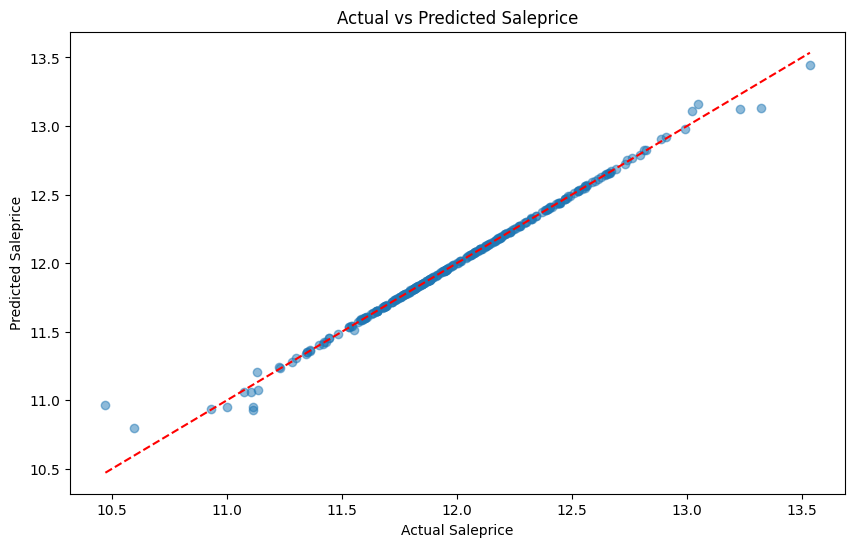

In [ ]:
# Plotting the final result.
plt.figure(figsize=(10,6))
plt.scatter(y_test,y_pred,alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Saleprice")
plt.ylabel("Predicted Saleprice")
plt.title("Actual vs Predicted Saleprice")
plt.show()

**Insights:**
The close clustering of points around the ideal prediction line confirms that the model generalizes well and produces reliable price estimates.

In [ ]:
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)
print("Train r2_score:",r2_score(y_train,y_train_pred))
print("Test r2_score:",r2_score(y_test,y_test_pred))

Train r2_score: 0.9998767911704903
Test r2_score: 0.9916174397759737


**Residual Analysis:**
Residual analysis was used to validate the assumptions of the regression model. The residuals were observed to be randomly distributed around zero without any clear pattern, indicating that the model does not suffer from systematic bias and is able to capture the underlying relationship effectively.

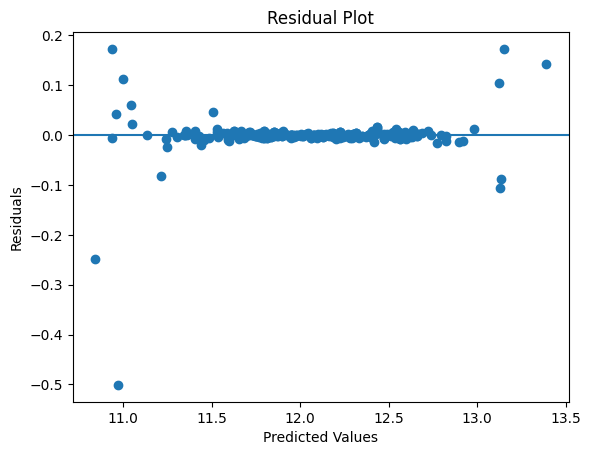

In [ ]:
residuals = y_test - y_test_pred
plt.figure()
plt.scatter(y_test_pred, residuals)
plt.axhline(0) # It draws a horizontal line across the plot.
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [ ]:
residuals = y_test - y_test_pred
residuals.sort_values().head(10)

,SalePrice_log
916,-0.501155
30,-0.247576
591,-0.106987
1243,-0.088218
1279,-0.081044
915,-0.024476
494,-0.019810
990,-0.015539
70,-0.014727
774,-0.013494


**Conclusion:**
A complete machine
learning pipeline was built including preprocessing, feature encoding, outlier handling and model training.
Among all the models, GradientBoosting Regressor achieved the best performance after hyperparameter tuning.
The final model achieved an r2_score of ~0.98 indicating strong predictive strong accuracy.Cross-validation result confirms that the model generalizes well to unseen data.

**Final Conclusion:**
In this project, an end-to-end machine learning pipeline was built to predict house prices using advanced regression techniques on the  Ames housing dataset.
After performing all the things the conclusion is
* The GradientBoosting Regressor performed the best among all the evaluated models.
*   It provided a good balance between bias and variance also captured non-linear realtionships in the data.


**Final Evaluation Metrics:**
RMSE : 11254.466409593886 ,
R2 Score:0.9834866196373769
These results indicates that the model explains a high proportion of variance in house price and produce reasonably low prediction error.

**Key Points**
* The model can help real estate companies predict fair market value before listing.
*  Developers can use insights to prioritize high-impact features like quality rating and living area.
*  Banks can also use this model to assess property value for loan approval.
* Future improvements include adding location based external data for higher accuracy











**Challenges Faced:**
*  High missing values in many columns(i.e.poolQC,Fence..)
*  The target column highly right skewed.
* Outliers present in numerical features(i.e.GrLivArea,LotArea,TotalBsmtmsf)
* Prevent data leakage risk at preprocessing steps
* Handled categorical variables, maintaining flexibility for multiple models
* Different models gave different result



